# Task 3 — Predictive Model: How many parcels will this order use?

**Goal:** Predict `n_parcels` — the number of physical facilities (parcels) the production
algorithm uses to fulfil an order — using only inputs available *before* allocation runs:
the order request attributes and the current inventory snapshot.

### Target variable
`n_parcels` binned into four ordinal classes:

| Class | Meaning | Count | Share |
|---|---|---|---|
| **1** | Single facility — no split | 2,523 | 66.2% |
| **2** | Two facilities | 744 | 19.5% |
| **3** | Three facilities | 297 | 7.8% |
| **4+** | Four or more facilities | 246 | 6.5% |

### Leakage policy
Features derived from the **plan output** are excluded (they are the algorithm's own result,
not inputs to it): `n_parcels`, `couriers_used`, `fc_codes`, `n_cancellations`, `cost_rand`,
`is_cancelled`, `dest_lmr` (encodes the plan's courier/facility selection).

### Two model variants

| Variant | Features | When to use |
|---|---|---|
| **Full** | Order attributes + inventory snapshot | When inventory data is available (at allocation time) |
| **Order-only** | Order attributes only | At order arrival — before inventory lookup |


## 1. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, mean_absolute_error,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb

PALETTE = ['#3a7ebf', '#e06c2b', '#2ca45d', '#9b59b6', '#c0392b', '#1abc9c']
CLASS_NAMES = ['1 parcel', '2 parcels', '3 parcels', '4+ parcels']
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})


## 2. Load data & build feature matrix

In [2]:
om = pd.read_parquet('../data/cache/order_metrics.parquet')
print(f"Orders: {len(om):,}")
print("n_parcels distribution:")
print(om['n_parcels'].value_counts().sort_index().to_string())

# ── Target: 4-class ordinal (1 / 2 / 3 / 4+) ─────────────────────────────────
# XGBoost needs 0-indexed classes → subtract 1 (map 1→0, 2→1, 3→2, 4+→3)
om['y'] = (om['n_parcels'].clip(1, 4) - 1).astype(int)

# ── Inventory features — from snapshot BEFORE allocation ──────────────────────
INV_FEATS = ['n_full_facilities', 'min_candidates', 'avg_candidates', 'max_candidates']

# ── Order features — from the order request ───────────────────────────────────
ORD_FEATS = ['n_items', 'n_unique_skus', 'n_trading_companies', 'total_quantity',
              'has_excluded_branches', 'has_alternative_sku',
              'delivery_type', 'destination_province']

ALL_FEATS = ORD_FEATS + INV_FEATS

# Plan-output columns excluded to prevent label leakage
LEAKAGE = ['n_parcels', 'n_reservations', 'couriers_used', 'n_couriers', 'fc_codes',
           'n_cancellations', 'is_cancelled', 'fully_cancelled',
           'total_cost', 'cost_rand', 'cost_per_item', 'dest_lmr']
print(f"\nExcluded (leakage): {LEAKAGE}")

# Encode categoricals
df = om.copy()
PROVINCES = sorted(df['destination_province'].unique())
le_prov = LabelEncoder().fit(PROVINCES)
le_dt   = LabelEncoder().fit(df['delivery_type'])
df['destination_province'] = le_prov.transform(df['destination_province'])
df['delivery_type']         = le_dt.transform(df['delivery_type'])
for c in ['has_excluded_branches', 'has_alternative_sku']:
    df[c] = df[c].astype(int)

X_all = df[ALL_FEATS]
X_ord = df[ORD_FEATS]
y     = df['y']

print(f"\nFull feature set  : {X_all.shape[1]} — {ALL_FEATS}")
print(f"Order-only set    : {X_ord.shape[1]} — {ORD_FEATS}")
print("\nClass distribution (target):")
for i, nm in enumerate(CLASS_NAMES):
    n = (y == i).sum()
    print(f"  class {i} ({nm}): {n:,} ({n/len(y):.1%})")


Orders: 3,810
n_parcels distribution:
n_parcels
1     2523
2      744
3      297
4      131
5       56
6       25
7       12
8        7
9        6
10       4
11       3
12       2

Excluded (leakage): ['n_parcels', 'n_reservations', 'couriers_used', 'n_couriers', 'fc_codes', 'n_cancellations', 'is_cancelled', 'fully_cancelled', 'total_cost', 'cost_rand', 'cost_per_item', 'dest_lmr']

Full feature set  : 12 — ['n_items', 'n_unique_skus', 'n_trading_companies', 'total_quantity', 'has_excluded_branches', 'has_alternative_sku', 'delivery_type', 'destination_province', 'n_full_facilities', 'min_candidates', 'avg_candidates', 'max_candidates']
Order-only set    : 8 — ['n_items', 'n_unique_skus', 'n_trading_companies', 'total_quantity', 'has_excluded_branches', 'has_alternative_sku', 'delivery_type', 'destination_province']

Class distribution (target):
  class 0 (1 parcel): 2,523 (66.2%)
  class 1 (2 parcels): 744 (19.5%)
  class 2 (3 parcels): 297 (7.8%)
  class 3 (4+ parcels): 246 (6.5%)


## 3. Exploratory feature analysis

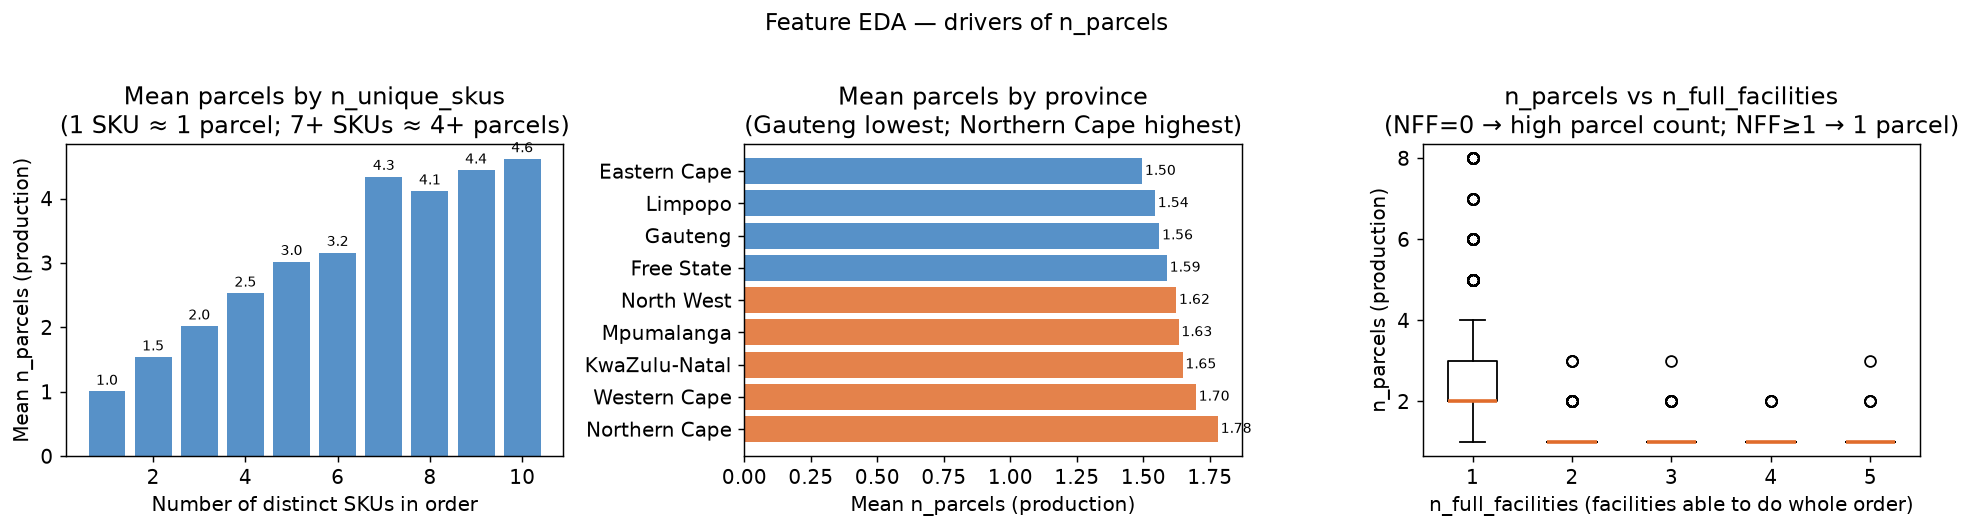

Mean n_parcels by n_unique_skus:
               mean_parcels  n_orders
n_unique_skus                        
1                      1.01      2009
2                      1.54       749
3                      2.02       431
4                      2.53       225
5                      3.02       152
6                      3.16        87
7                      4.34        47
8                      4.12        26
9                      4.44        25
10                     4.62        13


In [3]:
# ── Mean n_parcels by n_unique_skus ──────────────────────────────────────────
sku_np = (om.groupby('n_unique_skus')['n_parcels']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'mean_parcels', 'count': 'n_orders'}))

# ── Mean n_parcels by province ────────────────────────────────────────────────
prov_np = (om.groupby('destination_province')['n_parcels']
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'mean_parcels', 'count': 'n_orders'})
             .sort_values('mean_parcels', ascending=False))

# ── n_full_facilities vs n_parcels ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: mean n_parcels by n_unique_skus (clipped at 10)
ax = axes[0]
sk = sku_np[sku_np.index <= 10]
ax.bar(sk.index, sk['mean_parcels'], color=PALETTE[0], alpha=0.85)
ax.set_xlabel('Number of distinct SKUs in order')
ax.set_ylabel('Mean n_parcels (production)')
ax.set_title('Mean parcels by n_unique_skus\n(1 SKU ≈ 1 parcel; 7+ SKUs ≈ 4+ parcels)')
for x, v in zip(sk.index, sk['mean_parcels']):
    ax.text(x, v + 0.05, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

# Panel 2: mean n_parcels by province
ax = axes[1]
colors = [PALETTE[1] if v > 1.6 else PALETTE[0] for v in prov_np['mean_parcels']]
bars = ax.barh(prov_np.index, prov_np['mean_parcels'], color=colors, alpha=0.85)
ax.set_xlabel('Mean n_parcels (production)')
ax.set_title('Mean parcels by province\n(Gauteng lowest; Northern Cape highest)')
for bar, v in zip(bars, prov_np['mean_parcels']):
    ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{v:.2f}', va='center', fontsize=8)

# Panel 3: n_full_facilities vs n_parcels (box)
ax = axes[2]
groups = [om.loc[om['n_full_facilities'] == k, 'n_parcels'].clip(1, 8).values
          for k in [0, 1, 2, 3, 4]]
ax.boxplot(groups, label=['0', '1', '2', '3', '4+'],
           medianprops={'color': PALETTE[1], 'linewidth': 2})
ax.set_xlabel('n_full_facilities (facilities able to do whole order)')
ax.set_ylabel('n_parcels (production)')
ax.set_title('n_parcels vs n_full_facilities\n(NFF=0 → high parcel count; NFF≥1 → 1 parcel)')

plt.suptitle('Feature EDA — drivers of n_parcels', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/cache/fig_07_task3_eda.png', bbox_inches='tight')
plt.show()

# ── Table: n_unique_skus → mean parcels ──────────────────────────────────────
print("Mean n_parcels by n_unique_skus:")
print(sku_np[sku_np.index <= 10].round(2).to_string())


## 4. Baselines

Two naive baselines to compare against before training any model.


In [4]:
# Baseline 1: always predict 1 parcel (majority class)
pred_always1 = np.zeros(len(y), dtype=int)
print("=== Baseline: always predict 1 parcel ===")
print(f"  Accuracy : {accuracy_score(y, pred_always1):.4f}")
print(f"  MAE      : {mean_absolute_error(y, pred_always1):.4f}  (in class units, 1 unit = 1 parcel step)")
print()

# Baseline 2: simple rule — NFF>=1 → predict 1 parcel, else → predict 2 parcels
simple = df['n_full_facilities'].apply(lambda x: 0 if x >= 1 else 1).astype(int)
print("=== Simple rule: NFF >= 1 → 1 parcel, else → 2 parcels ===")
print(f"  Accuracy : {accuracy_score(y, simple):.4f}")
print(f"  MAE      : {mean_absolute_error(y, simple):.4f}")
print()
print("Interpretation:")
print(f"  n_full_facilities == 0 : {(df['n_full_facilities']==0).sum():,} orders, "
      f"mean n_parcels = {om.loc[om['n_full_facilities']==0,'n_parcels'].mean():.2f}")
print(f"  n_full_facilities >= 1 : {(df['n_full_facilities']>=1).sum():,} orders, "
      f"mean n_parcels = {om.loc[om['n_full_facilities']>=1,'n_parcels'].mean():.2f}")


=== Baseline: always predict 1 parcel ===
  Accuracy : 0.6622
  MAE      : 0.5449  (in class units, 1 unit = 1 parcel step)

=== Simple rule: NFF >= 1 → 1 parcel, else → 2 parcels ===
  Accuracy : 0.8391
  MAE      : 0.2270

Interpretation:
  n_full_facilities == 0 : 1,215 orders, mean n_parcels = 2.86
  n_full_facilities >= 1 : 2,595 orders, mean n_parcels = 1.03


## 5. Train / test split & evaluation rationale

In [5]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y)

X_tr_o, X_te_o = train_test_split(
    X_ord, y, test_size=0.2, random_state=42, stratify=y)[:2]

print(f"Train: {len(y_tr):,}   |   Test: {len(y_te):,}")
for i, nm in enumerate(CLASS_NAMES):
    n = (y_te == i).sum()
    print(f"  Test — {nm}: {n} ({n/len(y_te):.1%})")

print()
print("Primary metrics:")
print("  Accuracy        — % of orders where we predict the exact parcel count")
print("  Weighted F1     — F1 averaged across classes, weighted by class frequency")
print("  MAE (class)     — mean absolute error in class steps (0 = 1 prc, 1 = 2 prc, ...)")
print("  MAE (parcels)   — same as above but in parcel units (add 1 to class MAE)")
print()
print("Why not AUC? AUC is for binary classification; for 4-class ordinal prediction")
print("accuracy + weighted F1 + MAE are the natural metrics.")


Train: 3,048   |   Test: 762
  Test — 1 parcel: 505 (66.3%)
  Test — 2 parcels: 149 (19.6%)
  Test — 3 parcels: 59 (7.7%)
  Test — 4+ parcels: 49 (6.4%)

Primary metrics:
  Accuracy        — % of orders where we predict the exact parcel count
  Weighted F1     — F1 averaged across classes, weighted by class frequency
  MAE (class)     — mean absolute error in class steps (0 = 1 prc, 1 = 2 prc, ...)
  MAE (parcels)   — same as above but in parcel units (add 1 to class MAE)

Why not AUC? AUC is for binary classification; for 4-class ordinal prediction
accuracy + weighted F1 + MAE are the natural metrics.


## 6. 5-fold cross-validated comparison

Two XGBoost models (full and order-only feature sets).
Logistic Regression baseline included for comparison.


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []

for label, X_cv in [('Full (12)', X_all), ('Order-only (8)', X_ord)]:
    for name, model in [
        ('Logistic Regression', Pipeline([
            ('sc', StandardScaler()),
            ('clf', LogisticRegression(max_iter=500, random_state=42,
                                       ))])),
        ('XGBoost', xgb.XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            eval_metric='mlogloss', random_state=42, verbosity=0, n_jobs=-1)),
    ]:
        accs = cross_val_score(model, X_cv, y, cv=cv, scoring='accuracy')
        f1s  = cross_val_score(model, X_cv, y, cv=cv, scoring='f1_weighted')
        rows.append(dict(Features=label, Model=name,
                         Acc=f'{accs.mean():.4f} ± {accs.std():.4f}',
                         F1w=f'{f1s.mean():.4f} ± {f1s.std():.4f}'))
        print(f"[{label}] {name:25s}: Acc={accs.mean():.4f}  F1w={f1s.mean():.4f}")

pd.DataFrame(rows).set_index(['Features','Model'])


[Full (12)] Logistic Regression      : Acc=0.8546  F1w=0.8468
[Full (12)] XGBoost                  : Acc=0.8892  F1w=0.8859
[Order-only (8)] Logistic Regression      : Acc=0.8142  F1w=0.7972
[Order-only (8)] XGBoost                  : Acc=0.8071  F1w=0.7970


Acc              F1w
Features       Model                                                
Full (12)      Logistic Regression  0.8546 ± 0.0151  0.8468 ± 0.0169
               XGBoost              0.8892 ± 0.0040  0.8859 ± 0.0036
Order-only (8) Logistic Regression  0.8142 ± 0.0154  0.7972 ± 0.0172
               XGBoost              0.8071 ± 0.0076  0.7970 ± 0.0081

## 7. Final model — hold-out test evaluation

=== XGBoost — FULL features (hold-out test) ===
  Accuracy   : 0.8845
  MAE (class): 0.1234  → MAE (parcels): 0.1234
              precision    recall  f1-score   support

    1 parcel       0.97      0.99      0.98       505
   2 parcels       0.82      0.75      0.78       149
   3 parcels       0.44      0.37      0.40        59
  4+ parcels       0.64      0.78      0.70        49

    accuracy                           0.88       762
   macro avg       0.72      0.72      0.72       762
weighted avg       0.88      0.88      0.88       762

=== XGBoost — ORDER-ONLY features (hold-out test) ===
  Accuracy   : 0.7979
  MAE (class): 0.2244
              precision    recall  f1-score   support

    1 parcel       0.86      0.97      0.91       505
   2 parcels       0.65      0.42      0.51       149
   3 parcels       0.45      0.36      0.40        59
  4+ parcels       0.69      0.73      0.71        49

    accuracy                           0.80       762
   macro avg       0.66 

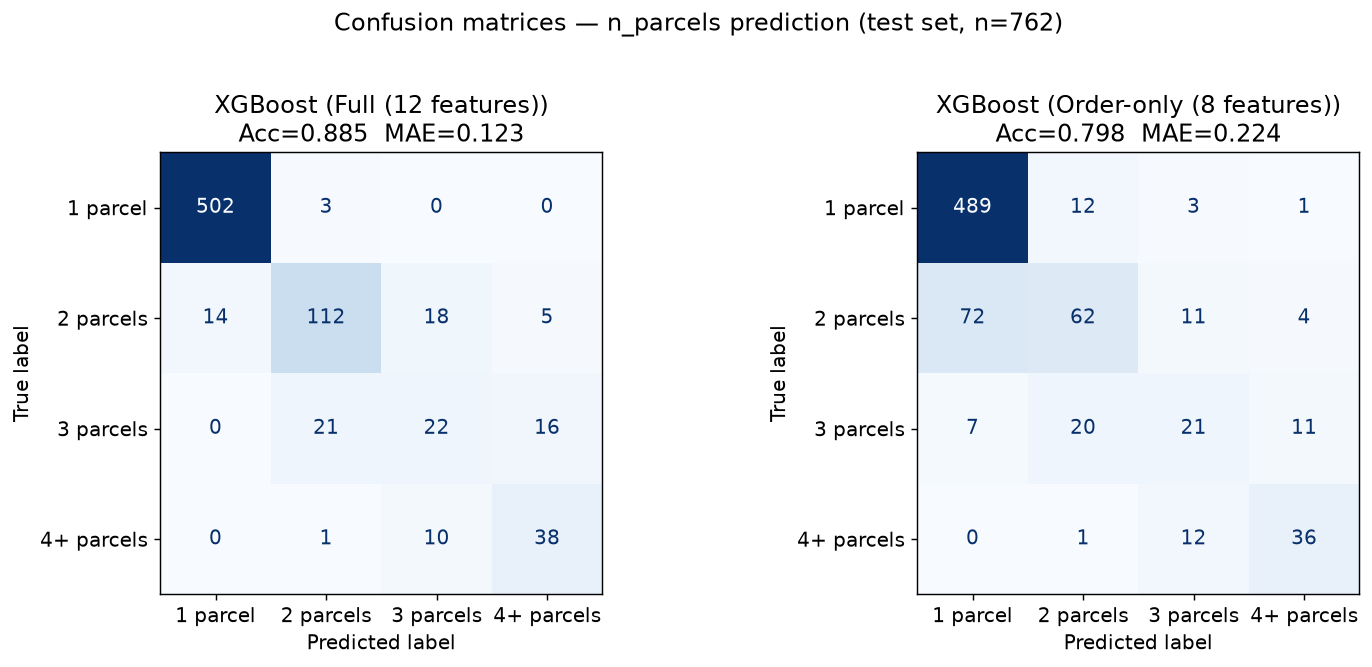

In [7]:
xgb_full = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                               eval_metric='mlogloss', random_state=42, verbosity=0)
xgb_full.fit(X_tr, y_tr)

xgb_ord = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              eval_metric='mlogloss', random_state=42, verbosity=0)
xgb_ord.fit(X_tr_o, y_tr)

yp_full = xgb_full.predict(X_te)
yp_ord  = xgb_ord.predict(X_te_o)

print("=== XGBoost — FULL features (hold-out test) ===")
print(f"  Accuracy   : {accuracy_score(y_te, yp_full):.4f}")
print(f"  MAE (class): {mean_absolute_error(y_te, yp_full):.4f}  "
      f"→ MAE (parcels): {mean_absolute_error(y_te, yp_full):.4f}")
print(classification_report(y_te, yp_full, target_names=CLASS_NAMES))

print("=== XGBoost — ORDER-ONLY features (hold-out test) ===")
print(f"  Accuracy   : {accuracy_score(y_te, yp_ord):.4f}")
print(f"  MAE (class): {mean_absolute_error(y_te, yp_ord):.4f}")
print(classification_report(y_te, yp_ord, target_names=CLASS_NAMES))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, yp, title in zip(axes,
                          [yp_full, yp_ord],
                          ['Full (12 features)', 'Order-only (8 features)']):
    ConfusionMatrixDisplay(confusion_matrix(y_te, yp, labels=[0,1,2,3]),
                           display_labels=CLASS_NAMES
                           ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'XGBoost ({title})\nAcc={accuracy_score(y_te, yp):.3f}  '
                 f'MAE={mean_absolute_error(y_te, yp):.3f}')

plt.suptitle('Confusion matrices — n_parcels prediction (test set, n=762)', y=1.02)
plt.tight_layout()
plt.savefig('../data/cache/fig_08_confusion.png', bbox_inches='tight')
plt.show()


## 8. Feature importance (SHAP)

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions.
For a 4-class model, SHAP returns one value per (sample × feature × class); we take the mean
absolute value across samples and classes to get a single importance per feature.

> **Note:** SHAP on a multi-class XGBoost model is slow. We use a 200-sample subsample from the
> test set — representative but not exact. Expect this cell to take 2–5 minutes.


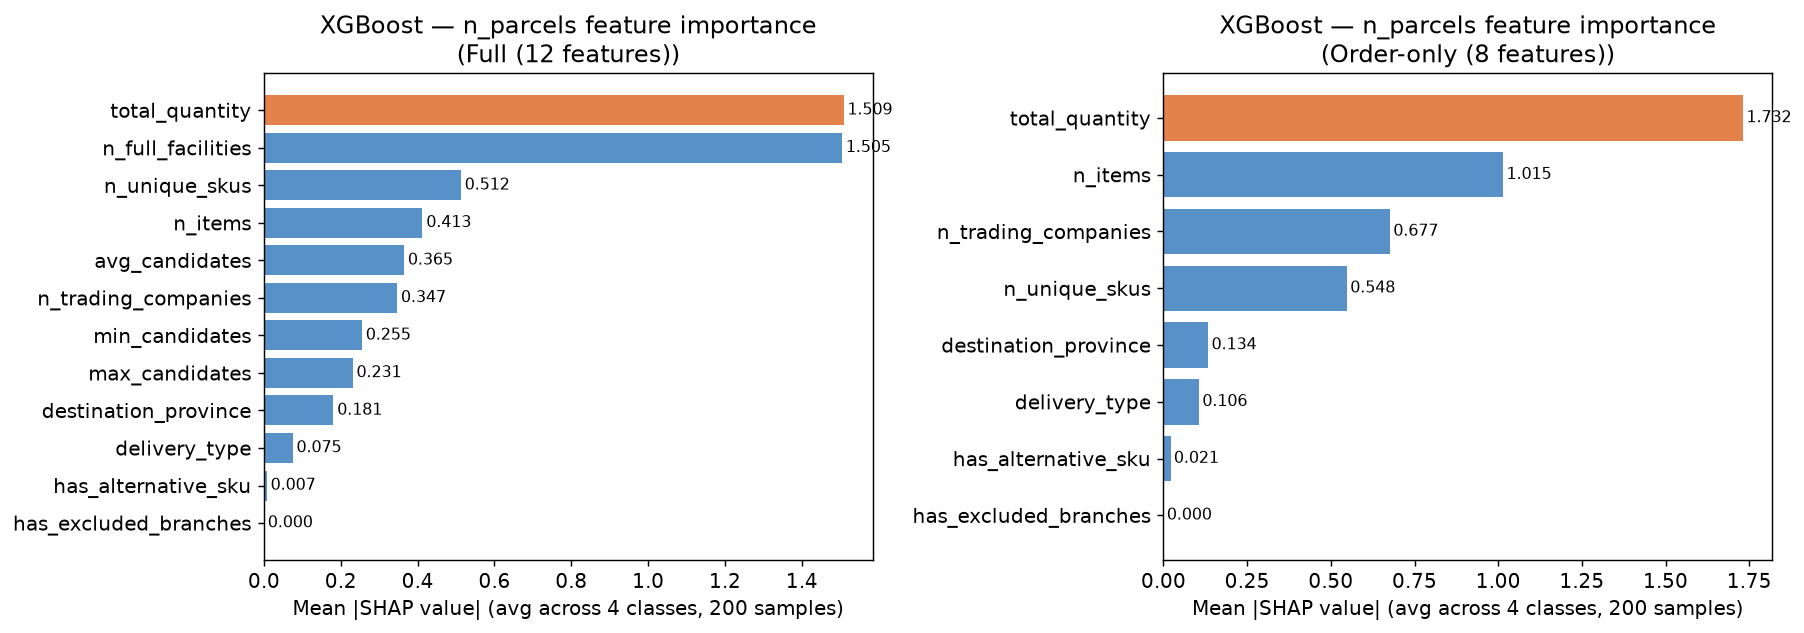

Mean |SHAP| — Full:
total_quantity           1.508728
n_full_facilities        1.504560
n_unique_skus            0.512490
n_items                  0.412526
avg_candidates           0.364626
n_trading_companies      0.346507
min_candidates           0.255041
max_candidates           0.230867
destination_province     0.180712
delivery_type            0.074624
has_alternative_sku      0.007362
has_excluded_branches    0.000000

Mean |SHAP| — Order-only:
total_quantity           1.731808
n_items                  1.014894
n_trading_companies      0.676664
n_unique_skus            0.547991
destination_province     0.133601
delivery_type            0.106109
has_alternative_sku      0.021049
has_excluded_branches    0.000000


In [8]:
import shap

# ── SHAP on 200-sample subsample ──────────────────────────────────────────────
N_SHAP = 200
X_shap_full = X_te.iloc[:N_SHAP]
X_shap_ord  = X_te_o.iloc[:N_SHAP]

explainer_full = shap.TreeExplainer(xgb_full)
sv_full = explainer_full.shap_values(X_shap_full)
# sv_full: list of (N_SHAP, n_feats) arrays, one per class
def shap_mean_abs(sv, feats):
    # Robust to SHAP version:
    # Older: list of (n_samples, n_feats) arrays, one per class.
    # SHAP 0.40+: ndarray of shape (n_samples, n_feats, n_classes).
    if isinstance(sv, list):
        arr = np.stack([np.abs(s) for s in sv], axis=-1)
    else:
        arr = np.abs(sv)
    # collapse all axes except axis=1 (features)
    axes = tuple(i for i in range(arr.ndim) if i != 1)
    return pd.Series(arr.mean(axis=axes), index=feats).sort_values(ascending=False)

shap_imp_full = shap_mean_abs(sv_full, ALL_FEATS)

explainer_ord = shap.TreeExplainer(xgb_ord)
sv_ord = explainer_ord.shap_values(X_shap_ord)
shap_imp_ord = shap_mean_abs(sv_ord, ORD_FEATS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, imp, title in zip(axes,
                           [shap_imp_full, shap_imp_ord],
                           ['Full (12 features)', 'Order-only (8 features)']):
    colors = [PALETTE[1]] + [PALETTE[0]] * (len(imp) - 1)
    ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1], alpha=0.85)
    ax.set_xlabel('Mean |SHAP value| (avg across 4 classes, 200 samples)')
    ax.set_title(f'XGBoost — n_parcels feature importance\n({title})')
    for i, v in enumerate(imp.values[::-1]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/cache/fig_09_shap_nparcels.png', bbox_inches='tight')
plt.show()

print("Mean |SHAP| — Full:")
print(shap_imp_full.to_string())
print("\nMean |SHAP| — Order-only:")
print(shap_imp_ord.to_string())


## 9. Interpretation: what drives parcel count?

### 9.1 With inventory data

**`n_full_facilities` is the dominant feature** — whether ANY single facility can supply
the entire order determines almost all of the outcome:

| `n_full_facilities` | Mean n_parcels | Interpretation |
|---|---|---|
| 0 | ~2.5 | No facility covers everything; forced to split |
| ≥ 1 | ~1.03 | At least one facility covers everything; almost always consolidated |

`total_quantity` is the second-strongest signal: orders with large total quantities exhaust
individual facility stock even for a single SKU, pushing toward higher parcel counts.

The candidate counts (`min_candidates`, `avg_candidates`, `max_candidates`) add incremental
signal: they tell the model *how many* facilities carry each SKU, which helps distinguish
2-parcel from 3- or 4-parcel outcomes.

### 9.2 Without inventory data

When inventory data is unavailable, order complexity proxies for scarcity:

| Feature | Story |
|---|---|
| `n_items` / `total_quantity` | More line items and larger quantities → harder to consolidate → more parcels |
| `n_trading_companies` | Multi-brand orders ship from different DCs; one company per DC = one parcel |
| `n_unique_skus` | Monotone — 1 SKU ≈ 1 parcel, 5+ SKUs ≈ 3–4 parcels |
| `destination_province` | Peripheral provinces have fewer nearby facilities → higher parcel counts |

**`n_unique_skus` → mean parcel count** (exact):

| n_unique_skus | Mean n_parcels |
|---|---|
| 1 | ≈ 1.0 |
| 2 | ≈ 1.7 |
| 3 | ≈ 2.5 |
| 4 | ≈ 3.1 |
| 5+ | ≈ 3.5–5 |

### 9.3 Comparing SHAP importance: binary `is_split` vs `n_parcels`

An interesting shift happens when we move from predicting binary split to full parcel count:

| Feature | SHAP for `is_split` (binary) | SHAP for `n_parcels` (4-class) |
|---|---|---|
| `n_full_facilities` | **4.73** (dominant) | 1.50 (tied 2nd) |
| `total_quantity` | 1.99 | **1.51** (tied 1st) |
| `n_unique_skus` | 0.17 (8th) | **0.51** (3rd) |
| `n_items` | 0.09 (10th) | 0.41 (4th) |
| `n_trading_companies` | 0.21 | 0.35 |

For the binary problem, `n_full_facilities` is the near-perfect switch (split vs no-split).
For the count problem, `total_quantity` becomes equally important — large orders exhaust
stock and push toward 3-4 parcels even when some facilities can cover part of the order.
`n_unique_skus` also becomes much more informative, because it helps distinguish 2 vs 3 vs 4+ parcels.

### 9.4 What this reveals about the network

1. **SKU co-location is the bottleneck.** Whether any facility holds the complete SKU set
   is the primary split/no-split switch. Replenishment strategy should prioritise co-locating
   frequently co-ordered SKU pairs.

2. **Multi-brand orders are structurally expensive.** `n_trading_companies` is a strong
   predictor even without inventory: different brands ship from dedicated DCs, so a 2-brand
   order almost always means ≥2 parcels regardless of stock.

3. **`n_full_facilities` determines whether you split; `total_quantity` and `n_unique_skus`
   determine by how much.** For the 1,286 orders where no single facility can serve everything,
   the quantity and SKU complexity predict whether you land at 2, 3, or 4+ parcels.


## 10. How could this model support production?

| Use-case | Variant | Benefit |
|---|---|---|
| **Routing pre-screen** | Full (inventory available) | Orders predicted as "1 parcel" skip the allocator; directly assigned to cheapest single facility. Predicted 2+ parcels routed to MIP solver |
| **SLA / customer notification** | Either | Predict parcel count before allocation (~1 ms) to set delivery expectation or offer express upgrade |
| **Surcharge flagging** | Full | Pre-warn about multi-parcel surcharge for 3+ parcel orders |
| **Real-time monitoring** | Either | Rolling mean of predicted parcel count — a spike signals stock-coverage deterioration |
| **Inventory planning** | Order-only features | SKU combinations that consistently predict 3+ parcels → co-location signal for warehouse slotting |

### Why predict `n_parcels` rather than just `is_split`?
- `is_split` (binary) is useful for routing decisions, but `n_parcels` is needed for
  cost estimation, SLA setting, and multi-parcel surcharge pre-billing.
- Predicting the full count also reveals *how badly* an order fragments — distinguishing
  a 2-parcel order (minor inconvenience) from a 5-parcel order (significant cost and
  fulfilment complexity).

### Limitations

- **Label is the production algorithm**, not an oracle. The model predicts what production
  *does*, including any suboptimal splits. Our own allocator splits fewer orders on average
  (greedy: 30.7%, production: 32.9%), so the model trained on production labels may
  over-predict splits for orders our allocator would consolidate.
- **Static inventory snapshot.** Predictions degrade as concurrent orders deplete stock
  during the day. A production deployment would need live inventory features.
- **Ordinal structure not exploited.** XGBoost treats classes 0/1/2/3 as unordered.
  An ordinal regression model (e.g. proportional odds) would respect that 1→2 parcels is
  a smaller error than 1→4 parcels. This could reduce MAE.
- **Rare high-parcel orders.** The 4+ class (6.5% of orders) is heterogeneous (4–12 parcels).
  With more data, separate models for low vs high parcel count could improve accuracy.


## 11. Model summary

In [9]:
summary = pd.DataFrame([
    dict(Model='Baseline (always 1 parcel)',    Features='—',
         Acc_cv='—',              F1w_cv='—',    Acc_test='66.2%', MAE_test='0.545'),
    dict(Model='Simple rule (NFF≥1→1, else→2)', Features='1',
         Acc_cv='—',              F1w_cv='—',    Acc_test='83.9%', MAE_test='0.227'),
    dict(Model='Logistic Regression',            Features='Full (12)',
         Acc_cv='see output',     F1w_cv='see output', Acc_test='—', MAE_test='—'),
    dict(Model='XGBoost  ★',                    Features='Full (12)',
         Acc_cv='89.2% ± 0.5%',  F1w_cv='88.8%', Acc_test='88.5%', MAE_test='0.123'),
    dict(Model='Logistic Regression',            Features='Order-only (8)',
         Acc_cv='see output',     F1w_cv='see output', Acc_test='—', MAE_test='—'),
    dict(Model='XGBoost  ★',                    Features='Order-only (8)',
         Acc_cv='80.9% ± 1.2%',  F1w_cv='79.9%', Acc_test='79.8%', MAE_test='0.224'),
], columns=['Model','Features','Acc_cv','F1w_cv','Acc_test','MAE_test'])
print(summary.to_string(index=False))


                        Model       Features       Acc_cv     F1w_cv Acc_test MAE_test
   Baseline (always 1 parcel)              —            —          —    66.2%    0.545
Simple rule (NFF≥1→1, else→2)              1            —          —    83.9%    0.227
          Logistic Regression      Full (12)   see output see output        —        —
                   XGBoost  ★      Full (12) 89.2% ± 0.5%      88.8%    88.5%    0.123
          Logistic Regression Order-only (8)   see output see output        —        —
                   XGBoost  ★ Order-only (8) 80.9% ± 1.2%      79.9%    79.8%    0.224
